In [1]:
import os
import re
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
class SGLX_readMeta:
    """Python port of SGLX_readMeta.m. Method names/semantics preserved."""

    # -----------------------------------------------------------------
    @staticmethod
    def ReadMeta(binName, path):
        """Parse the matching .meta file into a dict of strings."""
        # MATLAB fileparts() strips only the final extension:
        #   'foo.nidq.bin' -> name='foo.nidq'
        name = os.path.splitext(os.path.basename(binName))[0]
        metaName = name + ".meta"
        metaPath = Path(path) / metaName

        meta = {}
        with metaPath.open("r") as f:
            for line in f.read().splitlines():
                if "=" not in line:
                    continue
                tag, _, val = line.partition("=")
                if tag.startswith("~"):
                    tag = tag[1:]
                meta[tag] = val
        return meta

    # -----------------------------------------------------------------
    @staticmethod
    def ReadBin(samp0, nSamp, meta, binName, path):
        """Read nSamp timepoints starting at samp0. Returns [nChan x nSamp]
        float64 array (MATLAB reads as int16=>double)."""
        nChan = int(meta["nSavedChans"])
        nFileSamp = int(meta["fileSizeBytes"]) / (2 * nChan)

        samp0 = max(int(samp0), 0)
        nSamp = int(min(nSamp, nFileSamp - samp0))
        nSamp = max(nSamp, 0)

        binPath = Path(path) / binName
        with open(binPath, "rb") as f:
            f.seek(samp0 * 2 * nChan, os.SEEK_SET)
            count = nSamp * nChan
            raw = np.fromfile(f, dtype="<i2", count=count)

        nRead = raw.size // nChan
        # File is channel-interleaved per timepoint (row-major); MATLAB's
        # fread fills column-major into [nChan,nSamp] -> same result as
        # reshape (nRead, nChan) row-major then transpose.
        dataArray = raw[: nRead * nChan].reshape((nRead, nChan)).T.astype(np.float32)
        return dataArray

    # -----------------------------------------------------------------
    @staticmethod
    def ReadSyncBin(imec_firstSamp, imec_nSamp, imecMeta, imecBinName, binPath, imec_SY):
        """Read only the sync channel (last imec_SY channel(s))."""
        nChan = int(imecMeta["nSavedChans"])
        nFileSamp = int(imecMeta["fileSizeBytes"]) / (2 * nChan)

        imec_firstSamp = max(int(imec_firstSamp), 0)
        imec_nSamp = int(min(imec_nSamp, nFileSamp - imec_firstSamp))
        imec_nSamp = max(imec_nSamp, 0)

        sync_idx = nChan + imec_SY - 1  # 1-based row index of sync channel
        sync_idx0 = sync_idx - 1  # 0-based

        binFullPath = Path(binPath) / imecBinName
        itemsize = 2  # int16
        with open(binFullPath, "rb") as f:
            byteOffset = imec_firstSamp * 2 * nChan + sync_idx0 * itemsize
            f.seek(byteOffset, os.SEEK_SET)
            # Strided read: one int16 every nChan int16's
            raw = np.fromfile(f, dtype="<i2", count=imec_nSamp * nChan)

        # Only every nChan-th sample (starting at 0) belongs to this channel
        nGot = raw.size // nChan
        dataArray = raw[: nGot * nChan].reshape((nGot, nChan))[:, 0].astype(np.float32)
        return dataArray.reshape(1, -1)  # row vector, matches MATLAB .'

    # -----------------------------------------------------------------
    @staticmethod
    def SampRate(meta):
        t = meta.get("typeThis")
        if t == "imec":
            return float(meta["imSampRate"])
        elif t == "nidq":
            return float(meta["niSampRate"])
        elif t == "obx":
            return float(meta["obSampRate"])
        raise KeyError(f"Unknown typeThis: {t}")

    # -----------------------------------------------------------------
    @staticmethod
    def Int2Volts(meta):
        t = meta.get("typeThis")
        if t == "imec":
            maxInt = float(meta["imMaxInt"]) if "imMaxInt" in meta else 512.0
            return float(meta["imAiRangeMax"]) / maxInt
        elif t == "nidq":
            return float(meta["niAiRangeMax"]) / float(meta["niMaxInt"])
        elif t == "obx":
            return float(meta["obAiRangeMax"]) / float(meta["obMaxInt"])
        raise KeyError(f"Unknown typeThis: {t}")
    
    # -----------------------------------------------------------------
    @staticmethod
    def OriginalChans(meta):
        """Return 1-based list of original (acquired) channel IDs."""
        if meta.get("snsSaveChanSubset") == "all":
            return list(range(1, int(meta["nSavedChans"]) + 1))
        chans0 = _matlab_str2num_list(meta["snsSaveChanSubset"])
        return [c + 1 for c in chans0]

    # -----------------------------------------------------------------
    @staticmethod
    def ChannelCountsIM(meta):
        M = _matlab_str2num_list(meta["snsApLfSy"])
        return int(M[0]), int(M[1]), int(M[2])

    @staticmethod
    def ChannelCountsNI(meta):
        M = _matlab_str2num_list(meta["snsMnMaXaDw"])
        return int(M[0]), int(M[1]), int(M[2]), int(M[3])

    @staticmethod
    def ChannelCountsOBX(meta):
        M = _matlab_str2num_list(meta["snsXaDwSy"])
        return int(M[0]), int(M[1]), int(M[2])

    # -----------------------------------------------------------------
    @staticmethod
    def ChanGainNI(ichan, savedMN, savedMA, meta):
        """ichan is 1-based saved-channel index."""
        if ichan <= savedMN:
            return float(meta["niMNGain"])
        elif ichan <= savedMN + savedMA:
            return float(meta["niMAGain"])
        else:
            return 1.0

    # -----------------------------------------------------------------
    @staticmethod
    def ChanGainsIM(meta):
        np1_imro = [0, 1020, 1030, 1200, 1100, 1120, 1121, 1122, 1123, 1300]
        acqCountList = _matlab_str2num_list(meta["acqApLfSy"])

        APgain = np.zeros(int(acqCountList[0]))
        LFgain = np.zeros(int(acqCountList[1]))

        probeType = float(meta["imDatPrb_type"]) if "imDatPrb_type" in meta else 0

        if probeType in np1_imro:
            APgain, LFgain = _parse_imro_gains(meta["imroTbl"])
        else:
            if "imChan0apGain" in meta:
                APgain = APgain + float(meta["imChan0apGain"])
                if acqCountList[1] > 0:
                    LFgain = LFgain + float(meta["imChan0lfGain"])
            elif probeType == 1110:
                nums = [float(x) for x in re.findall(r"-?\d+", meta["imroTbl"])[:5]]
                APgain = APgain + nums[3]
                LFgain = LFgain + nums[4]
            elif probeType in (21, 24):
                APgain = APgain + 80
            elif probeType == 2013:
                APgain = APgain + 100
            else:
                print("unknown gain, setting APgain to 1")
                APgain = APgain + 1

        fI2V = SGLX_readMeta.Int2Volts(meta)
        APChan0_to_uV = 1e6 * fI2V / APgain[0]
        LFChan0_to_uV = 1e6 * fI2V / LFgain[0] if LFgain.size > 0 else 0
        return APgain, LFgain, APChan0_to_uV, LFChan0_to_uV

    # -----------------------------------------------------------------
    @staticmethod
    def GainCorrectNI(dataArray, chanList, meta):
        """chanList: 1-based saved-channel indices (MATLAB convention)."""
        MN, MA, XA, DW = SGLX_readMeta.ChannelCountsNI(meta)
        fI2V = SGLX_readMeta.Int2Volts(meta)
        out = dataArray  # modify in place (avoid doubling memory)
        for j in chanList:
            conv = fI2V / SGLX_readMeta.ChanGainNI(j, MN, MA, meta)
            out[j - 1, :] = out[j - 1, :] * conv
        return out

    @staticmethod
    def GainCorrectOBX(dataArray, chanList, meta):
        fI2V = SGLX_readMeta.Int2Volts(meta)
        out = dataArray  # modify in place (avoid doubling memory)
        for j in chanList:
            out[j - 1, :] = out[j - 1, :] * fI2V
        return out

    @staticmethod
    def GainCorrectIM(dataArray, chanList, meta):
        """chanList: 1-based saved-channel indices (MATLAB convention)."""
        chans = SGLX_readMeta.OriginalChans(meta)  # 1-based, len == nSavedChans
        APgain, LFgain, _, _ = SGLX_readMeta.ChanGainsIM(meta)
        nAP = len(APgain)
        nNu = nAP * 2

        fI2V = SGLX_readMeta.Int2Volts(meta)
        out = dataArray  # modify in place (avoid doubling memory)
        for j in chanList:
            k = chans[j - 1]  # acquisition index (1-based)
            if k <= nAP:
                conv = fI2V / APgain[k - 1]
            elif k <= nNu:
                conv = fI2V / LFgain[k - nAP - 1]
            else:
                continue
            out[j - 1, :] = out[j - 1, :] * conv
        return out

def _matlab_str2num_list(s):
    """Parse a MATLAB str2num-style numeric list, e.g. '384,0,1' or
    '0:33,36:37,40' into a flat list of ints/floats."""
    vals = []
    for part in s.split(","):
        part = part.strip()
        if not part:
            continue
        if ":" in part:
            lo, hi = part.split(":")
            vals.extend(range(int(lo), int(hi) + 1))
        else:
            vals.append(float(part) if "." in part else int(part))
    return vals

In [3]:
class sliderLog:
    """Python port of sliderLog.m."""

    @staticmethod
    def getCsv(csvFiles):
        """csvFiles: list of full paths to .csv files (already filtered)."""
        csvData = []
        for f in csvFiles:
            csvData.append((os.path.basename(f), pd.read_csv(f)))

        for i, (name, _) in enumerate(csvData):
            print(f"[{i + 1}] {name}")
        j = int(input("Insert related csv file number: ")) - 1
        csvName = csvData[j][0]
        print(csvName)
        data = csvData[j][1]
        return csvData, csvName, data

    @staticmethod
    def classifyCsv(data, motor_start, motor_end):
        data = data.copy()

        # 1) Make corrected angle: if direction==0, add 180 degrees
        idx = data["direction"] == 0
        data.loc[idx, "stepper_ang"] = data.loc[idx, "stepper_ang"] + 180

        # 2) Find unique speeds and angles
        spList = np.sort(data["cmd_speed"].unique())
        angList = np.sort(data["stepper_ang"].unique())

        # 3) data form change
        motor_start = np.asarray(motor_start)
        motor_end = np.asarray(motor_end)

        data["nidq_start"] = motor_start
        start_time = pd.to_datetime(data["start_time"])
        end_time = pd.to_datetime(data["end_time"])
        data["log_dur"] = (end_time - start_time).dt.total_seconds()
        data["trig_dur"] = motor_end - motor_start
        data["log_end"] = data["nidq_start"] + data["log_dur"]
        data["trig_end"] = motor_end

        data = data.drop(columns=["direction", "result", "notes", "end_time"], errors="ignore")
        return spList, angList, data

    @staticmethod
    def groupingCsv(data, spList, angList):
        csvGroup = {}
        for sp in spList:
            spField = make_valid_name(f"sp_{sp:g}")
            spTable = data[data["cmd_speed"] == sp]
            csvGroup[spField] = {}
            for ang in angList:
                angField = make_valid_name(f"ang_{ang:g}")
                angTable = spTable[spTable["stepper_ang"] == ang].reset_index(drop=True)
                csvGroup[spField][angField] = angTable

        repeatTime = len(data) / (len(spList) * len(angList))
        return csvGroup, repeatTime

In [4]:
def bpfft(v, rate, fo, f1):
    """Band-pass fft filter, pass band fo < f < f1 (Hz).
    Direct port of bpfft.m; operates on a 1-D signal."""
    v = np.asarray(v, dtype=float).ravel()
    n = v.size

    ffo = int(round(fo * n / rate))
    ff1 = int(round(f1 * n / rate))
    fb = np.fft.fft(v)

    if fo == 0:
        ffo = -1

    # MATLAB 1-based ranges: [1:ffo+1, ff1+1:n-ff1+1, n-ffo+1:n]
    idx = []
    if ffo + 1 >= 1:
        idx.append(np.arange(1, ffo + 2))
    lo2, hi2 = ff1 + 1, n - ff1 + 1
    if hi2 >= lo2:
        idx.append(np.arange(lo2, hi2 + 1))
    lo3, hi3 = n - ffo + 1, n
    if hi3 >= lo3:
        idx.append(np.arange(lo3, hi3 + 1))

    if idx:
        idx = np.concatenate(idx) - 1  # to 0-based
        idx = idx[(idx >= 0) & (idx < n)]
        fb[idx] = 0

    d = np.real(np.fft.ifft(fb))
    return d

def read_cluster_kslabel_tsv(tsv_path):
    return pd.read_csv(
        tsv_path, sep="\t", header=0, names=["cluster_id", "KSLabel"],
        dtype={"cluster_id": float, "KSLabel": str},
    )

def make_valid_name(s):
    """Equivalent of matlab.lang.makeValidName (simplified)."""
    s = re.sub(r"[^0-9a-zA-Z_]", "_", str(s))
    if not s or not s[0].isalpha():
        s = "x" + s
    return s

In [75]:
def draw_ridgeplot(df, axes, palette):
    groups = ['1200', '800', '400', '50']
    for ax, group, color in zip(axes, groups, palette):
        data = df[df["speed"] == group]
        vals = data["spike_timing"].dropna()
        #determine the proper time range for the speed
        if group == '1200': data_range = 0.084
        elif group == '800': data_range = 0.125
        elif group == '400': data_range = 0.25
        elif group == '50': data_range = 2
        n_bins = max(1, int(np.ceil(data_range / 0.002)))
        sns.histplot(data=data, x="spike_timing", bins = n_bins, stat="count",
            linewidth=0.4, color=color, ax=ax)
        #set axes
        ax.set_xlim(0, data_range)
        ax.set_ylim(0, 8)
        # Label for each ridge
        ax.text(-0.15, .2, group, transform=ax.transAxes, fontweight="bold",
            color=color, ha="right", va="center")
        # Remove clutter
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.set_facecolor("none")
        # Colored baseline
        #ax.axhline(0, color="black", lw=2)
    axes[-1].set_xlabel("Spike timing (s)")

In [32]:
def plot_cluster(cluster, ridge_datasets, outDir = None):
    palette = sns.cubehelix_palette(4, rot=-.25, light=.7)
    fig = plt.figure(figsize=(12,10))
    outer = fig.add_gridspec(3,3,hspace=0.4,wspace=0.4)
    positions = [
        (0,0),(0,1),(0,2),
        (1,0),(1,2),
        (2,0),(2,1),(2,2)]
    angle_order = [135,90,45,180,0,225,270,-45]

    for angle, (r,c) in zip(angle_order, positions):
        #n = len(ridge_datasets[angle]["speed"].unique())
        #print(n)
        n = 4 #number of speeds
        inner = outer[r,c].subgridspec(n,1,hspace=0.3)
        axes = inner.subplots()
        draw_ridgeplot(ridge_datasets[angle], axes, palette)
        axes[0].set_title(f"{angle}°")

    figTitle = f"Cluster {cluster}"
    fig.suptitle(figTitle, fontsize=16)
    if outDir is not None:
        fileName = make_valid_name(figTitle)
        plt.savefig(os.path.join(outDir, fileName + ".png"))

    plt.show()

In [64]:
def one_cluster_data(sel,spike_sec,spike_clusters):
    selected_cluster = sel

    # From here on, spike_sec / spike_clusters only contain this one unit's spikes.
    mask = spike_clusters == selected_cluster
    spike_sec = spike_sec_all[mask]
    spike_clusters = spike_clusters_all[mask]

    trigger_signal = nidq_V[2, :]  # channel 3 (1-based in MATLAB) -> index 2

    thr_down = 0.1
    thr_up = 2.2

    above_up = trigger_signal > thr_up
    below_down = trigger_signal < thr_down
    rising_indices = np.where(np.diff(above_up.astype(int)) == 1)[0] + 1
    falling_indices = np.where(np.diff(below_down.astype(int)) == 1)[0] - 1
    
    motor_start = nidq_t[rising_indices]
    motor_end = nidq_t[falling_indices]

    spList, angList, updateCsv = sliderLog.classifyCsv(oneCsv, motor_start, motor_end)

    updateCsv = updateCsv.reset_index(drop=True)
    spike_timing = [None] * len(motor_start)
    spike_rates = np.zeros(len(motor_start))
    
    for k in range(len(motor_start)):
        tStart = updateCsv["nidq_start"].iloc[k]
        tEnd = updateCsv["trig_end"].iloc[k]
        idx = (spike_sec >= tStart) & (spike_sec <= tEnd)
    
        spike_timing[k] = spike_sec[idx]
        spike_rates[k] = idx.sum() / updateCsv["log_dur"].iloc[k]
    
    updateCsv["spike_timing"] = spike_timing
    updateCsv["spike_rates"] = spike_rates

    csvGroup, repeatTime = sliderLog.groupingCsv(updateCsv, spList, angList)
    
    return csvGroup, spList, angList

In [12]:
def build_ridge_datasets(cluster, csvGroup, angList, spList):
    ridge_datasets = {}
    for ang in angList:
        angName = make_valid_name(f"ang_{ang:g}")
        rows = []

        for sp in spList:
            spName = make_valid_name(f"sp_{sp:g}")
            T = csvGroup[spName][angName]

            all_spikes = []

            for k in range(len(T)):
                spRel = (np.asarray(T["spike_timing"].iloc[k]) - T["nidq_start"].iloc[k])
                spRel = spRel[(spRel >= -0.5) & (spRel <= 2.0)]
                all_spikes.extend(spRel)

            rows.extend({"spike_timing": s, "speed": f"{sp:g}"} for s in all_spikes)

        ridge_datasets[ang] = pd.DataFrame(rows)

    return ridge_datasets

### getData: start from step01_rawData

In [35]:
# Windows absolute path -- use a raw string (r"...") so backslashes
# aren't treated as escape characters, or use forward slashes instead.
folderPath = r"C:\Users\mymcm\OneDrive - Northwestern University\Hartmann Lab - Mitra Hartmann - expt_260605_rat17"

assert os.path.isdir(folderPath), f"Folder not found: {folderPath}"

allFiles = glob.glob(os.path.join(folderPath, "**", "*"), recursive=True)
binNidqFiles = [f for f in allFiles if f.endswith(".nidq.bin")]
binImecFiles = [f for f in allFiles if f.endswith(".imec0.ap.bin")]
csvFiles = [f for f in allFiles if f.endswith(".csv")]

print(f"Found {len(binNidqFiles)} nidq.bin, {len(binImecFiles)} imec0.ap.bin, {len(csvFiles)} csv files")

print("\nbinNidqFiles:")
for idx, f in enumerate(binNidqFiles):
    print(f"[{idx + 1}] {f}")

Found 18 nidq.bin, 10 imec0.ap.bin, 31 csv files

binNidqFiles:
[1] C:\Users\mymcm\OneDrive - Northwestern University\Hartmann Lab - Mitra Hartmann - expt_260605_rat17\rat17_ap3000_ml4600_dv1320_g0\rat17_ap3000_ml4600_dv1320_g0_t0.nidq.bin
[2] C:\Users\mymcm\OneDrive - Northwestern University\Hartmann Lab - Mitra Hartmann - expt_260605_rat17\rat17_ap3000_ml4600_dv1600_02_g0\rat17_ap3000_ml4600_dv1600_02_g0_t0.nidq.bin
[3] C:\Users\mymcm\OneDrive - Northwestern University\Hartmann Lab - Mitra Hartmann - expt_260605_rat17\rat17_ap3000_ml4600_dv1600_02_g0\copy\rat17_ap3000_ml4600_dv1600_02_g0_t0.nidq.bin
[4] C:\Users\mymcm\OneDrive - Northwestern University\Hartmann Lab - Mitra Hartmann - expt_260605_rat17\rat17_ap3000_ml4600_dv1600_B4_g0\rat17_ap3000_ml4600_dv1600_B4_g0_t0.nidq.bin
[5] C:\Users\mymcm\OneDrive - Northwestern University\Hartmann Lab - Mitra Hartmann - expt_260605_rat17\rat17_ap3000_ml4600_dv1600_g0\rat17_ap3000_ml4600_dv1600_g0_t0.nidq.bin
[6] C:\Users\mymcm\OneDrive - Nor

In [36]:
j = int(input("which neural data number do you want to analyze? ")) - 1  # MATLAB is 1-indexed
imecFilePath = binImecFiles[j]
binPath = os.path.dirname(imecFilePath)
binNameFull = os.path.basename(imecFilePath)
binName = binNameFull[: -len(".imec0.ap.bin")]
print(binName)
print(binPath)

# 1) Read metadata
imecBinName = binName + ".imec0.ap.bin"
imecMeta = SGLX_readMeta.ReadMeta(imecBinName, binPath)

nidqBinName = binName + ".nidq.bin"
nidqParentPath = os.path.dirname(binPath)  # fileparts(binPath)
nidqMeta = SGLX_readMeta.ReadMeta(nidqBinName, nidqParentPath)

rec_time = float(imecMeta["fileTimeSecs"])  # imec/nidq timesecs differ slightly, ignored
print(rec_time)

which neural data number do you want to analyze?  2


rat17_ap3000_ml4600_dv1600_02_g0_t0
C:\Users\mymcm\OneDrive - Northwestern University\Hartmann Lab - Mitra Hartmann - expt_260605_rat17\rat17_ap3000_ml4600_dv1600_02_g0\rat17_ap3000_ml4600_dv1600_02_g0_imec0
910.8197


In [37]:
csvData, csvName, oneCsv = sliderLog.getCsv(csvFiles)
# should match the neural data directly above

[1] rat17_ap3000_ml4600_dv1320_2026-06-05-22-01-40.csv
[2] rat17_ap3000_ml4600_dv1600_02_2026-06-05-23-05-05.csv
[3] rat17_ap3000_ml4600_dv1600_2026-06-05-22-28-58.csv
[4] rat17_ap3000_ml4600_dv1600_B4_2026-06-06-00-06-30.csv
[5] rat17_ap3000_ml4600_dv1600_sur_2026-06-05-23-47-02.csv
[6] rat17_ap3200_ml4600_dv1580_2026-06-05-17-50-43.csv
[7] rat17_ap3200_ml4600_dv1800_2026-06-05-18-28-21.csv
[8] rat17_ap3200_ml5100_dv1500_02_2026-06-05-19-47-47.csv
[9] rat17_ap3200_ml5100_dv1500_03_2026-06-05-20-17-37.csv
[10] rat17_ap3200_ml5100_dv1500_2026-06-05-19-12-47.csv
[11] rat17_ap3200_ml5100_dv1700_2026-06-05-20-46-20.csv
[12] rat17_ap3200_ml5100_dv1700_2_2026-06-05-21-26-52.csv
[13] rat17_cal_01_2026-06-05-14-00-42.csv
[14] rat17_cal_01_2026-06-05-15-32-46.csv
[15] rat17_cal_02_2026-06-05-19-41-58.csv
[16] rat17_cal_03_2026-06-05-20-07-29.csv
[17] rat17_cal_04_2026-06-05-22-57-32.csv
[18] rat17_cal_post_2026-06-06-00-34-16.csv
[19] rat17_test_01_2026-06-05-22-47-19.csv
[20] rat17_test_cal_20

Insert related csv file number:  2


rat17_ap3000_ml4600_dv1600_02_2026-06-05-23-05-05.csv


In [74]:
nidq_fs = float(nidqMeta["niSampRate"])

nidq_firstSamp = max(0, round(0 * nidq_fs))
nidq_nSamp = max(1, round(rec_time * nidq_fs))

nidq_raw = SGLX_readMeta.ReadBin(0, nidq_nSamp, nidqMeta, nidqBinName, nidqParentPath)
nidq_V = SGLX_readMeta.GainCorrectNI(nidq_raw, range(1, nidq_raw.shape[0] + 1), nidqMeta)
nidq_t = np.arange(nidq_raw.shape[1]) / nidq_fs
nidq_Wstart = 0
nidq_Wend = max(1, round(rec_time * nidq_fs))

In [39]:
j2 = int(input("which calibration data number do you want to use? ")) - 1
calFilePath = binNidqFiles[j2]
calBinPath = os.path.dirname(calFilePath)
calBinName = os.path.basename(calFilePath)
print(calBinName)

calMeta = SGLX_readMeta.ReadMeta(calBinName, calBinPath)

which calibration data number do you want to use?  18


rat17_cal_04_g1_t0.nidq.bin


In [40]:
imec_fs = float(imecMeta["imSampRate"])
imec_AP, imec_LF, imec_SY = SGLX_readMeta.ChannelCountsIM(imecMeta)

ksDir = os.path.join(binPath, "Kilosort4")
spike_times = np.load(os.path.join(ksDir, "spike_times.npy"))       # sample index per spike
spike_clusters = np.load(os.path.join(ksDir, "spike_clusters.npy")) # cluster/template id per spike
spike_sec = spike_times.astype(float) / imec_fs                     # -> seconds

#462x61x384
templates = np.load(os.path.join(ksDir, "templates.npy"))           # Full time x channels template shapes
templates_ind = np.load(os.path.join(ksDir, "templates_ind.npy"))

# Prefer bombcell's unit classification (cluster_bc_unitType.tsv, label
# 'GOOD'); fall back to Kilosort's own cluster_KSLabel.tsv (label 'good')
# if bombcell output isn't present.
bcFile = os.path.join(ksDir, "cluster_bc_unitType.tsv")
ksFile = os.path.join(ksDir, "cluster_KSLabel.tsv")

if os.path.exists(bcFile):
    clusterLabels = pd.read_csv(bcFile, sep="\t")
    goodClusters = clusterLabels.loc[clusterLabels["bc_unitType"] == "GOOD", "cluster_id"].to_numpy()
    print(f"Using bombcell labels ({os.path.basename(bcFile)}): {len(goodClusters)} good units")
else:
    clusterLabels = read_cluster_kslabel_tsv(ksFile)
    goodClusters = clusterLabels.loc[clusterLabels["KSLabel"] == "good", "cluster_id"].to_numpy()
    print(f"bombcell labels not found -- using Kilosort labels ({os.path.basename(ksFile)}): {len(goodClusters)} good units")

idxGoodSpike = np.isin(spike_clusters.astype(float), goodClusters)
spike_sec = spike_sec[idxGoodSpike]
spike_clusters = spike_clusters[idxGoodSpike]
goodClusterIDs = np.sort(goodClusters)

print(f"{len(goodClusterIDs)} good units, {spike_sec.size} total spikes")

Using bombcell labels (cluster_bc_unitType.tsv): 16 good units
16 good units, 38634 total spikes


In [41]:
print("Good cluster IDs:")
for idx, cid in enumerate(goodClusterIDs):
    n_spikes = int(np.sum(spike_clusters == cid))
    print(f"[{idx + 1}] cluster {cid}  ({n_spikes} spikes)")

spike_sec_all = spike_sec
spike_clusters_all = spike_clusters

Good cluster IDs:
[1] cluster 0  (342 spikes)
[2] cluster 86  (2932 spikes)
[3] cluster 208  (2287 spikes)
[4] cluster 217  (1847 spikes)
[5] cluster 233  (1058 spikes)
[6] cluster 269  (1191 spikes)
[7] cluster 309  (775 spikes)
[8] cluster 338  (12794 spikes)
[9] cluster 346  (5516 spikes)
[10] cluster 347  (675 spikes)
[11] cluster 350  (3264 spikes)
[12] cluster 356  (347 spikes)
[13] cluster 364  (521 spikes)
[14] cluster 365  (623 spikes)
[15] cluster 369  (3307 spikes)
[16] cluster 410  (1155 spikes)


limit goodClusterIDs to only be clusters with >1000 spikes

In [42]:
bigGoodClusterIDs = list(filter(lambda cid: int(np.sum(spike_clusters == cid)) > 1000, goodClusterIDs))

print("Big good cluster IDs:")
for idx, cid in enumerate(bigGoodClusterIDs):
    n_spikes = int(np.sum(spike_clusters == cid))
    print(f"[{idx + 1}] cluster {cid}  ({n_spikes} spikes)")

Big good cluster IDs:
[1] cluster 86  (2932 spikes)
[2] cluster 208  (2287 spikes)
[3] cluster 217  (1847 spikes)
[4] cluster 233  (1058 spikes)
[5] cluster 269  (1191 spikes)
[6] cluster 338  (12794 spikes)
[7] cluster 346  (5516 spikes)
[8] cluster 350  (3264 spikes)
[9] cluster 369  (3307 spikes)
[10] cluster 410  (1155 spikes)


In [21]:
outDir = os.path.join(os.path.dirname(binPath), "spikeHistograms")
os.makedirs(outDir, exist_ok=True)

In [ ]:
#testing with only two clusters
for cluster in [86, 208]:
    csvGroup, spList, angList = one_cluster_data(cluster,spike_sec_all,spike_clusters_all)

    ridge_datasets = build_ridge_datasets(cluster, csvGroup, angList, spList)

    plot_cluster(cluster, ridge_datasets)

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


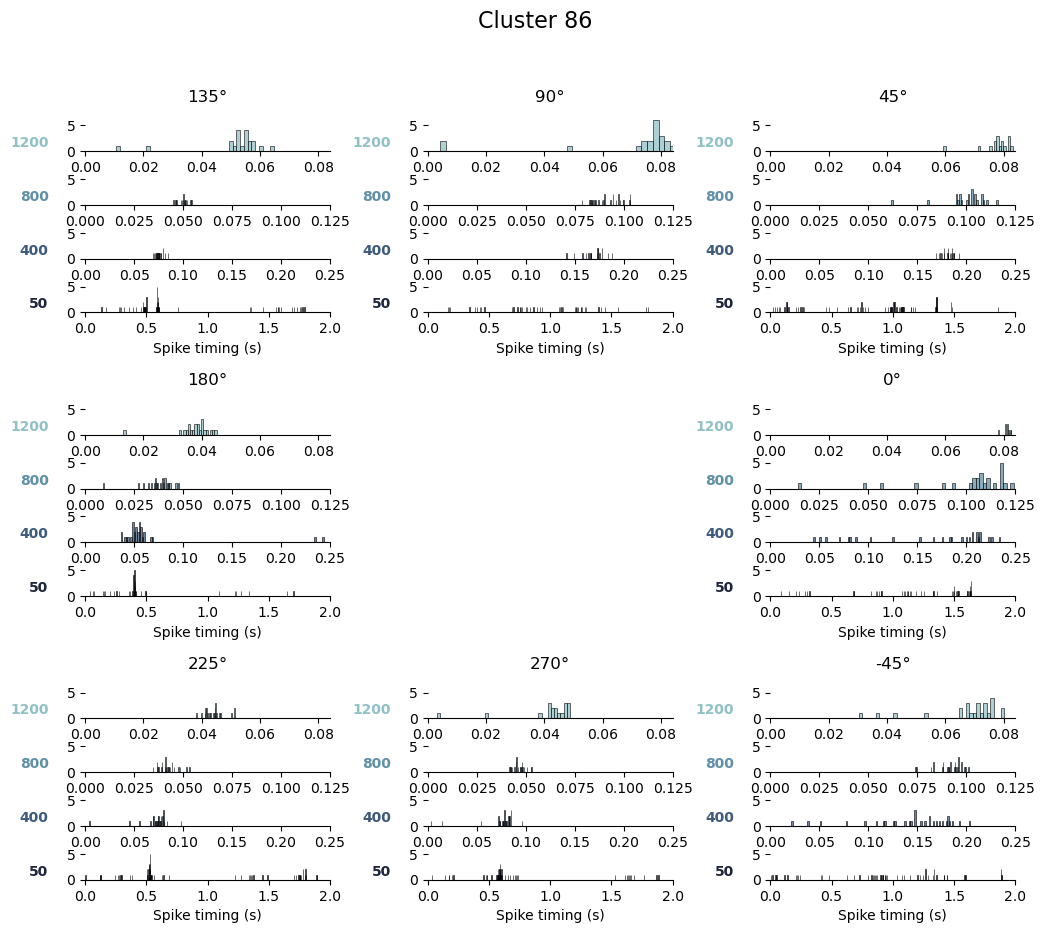

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


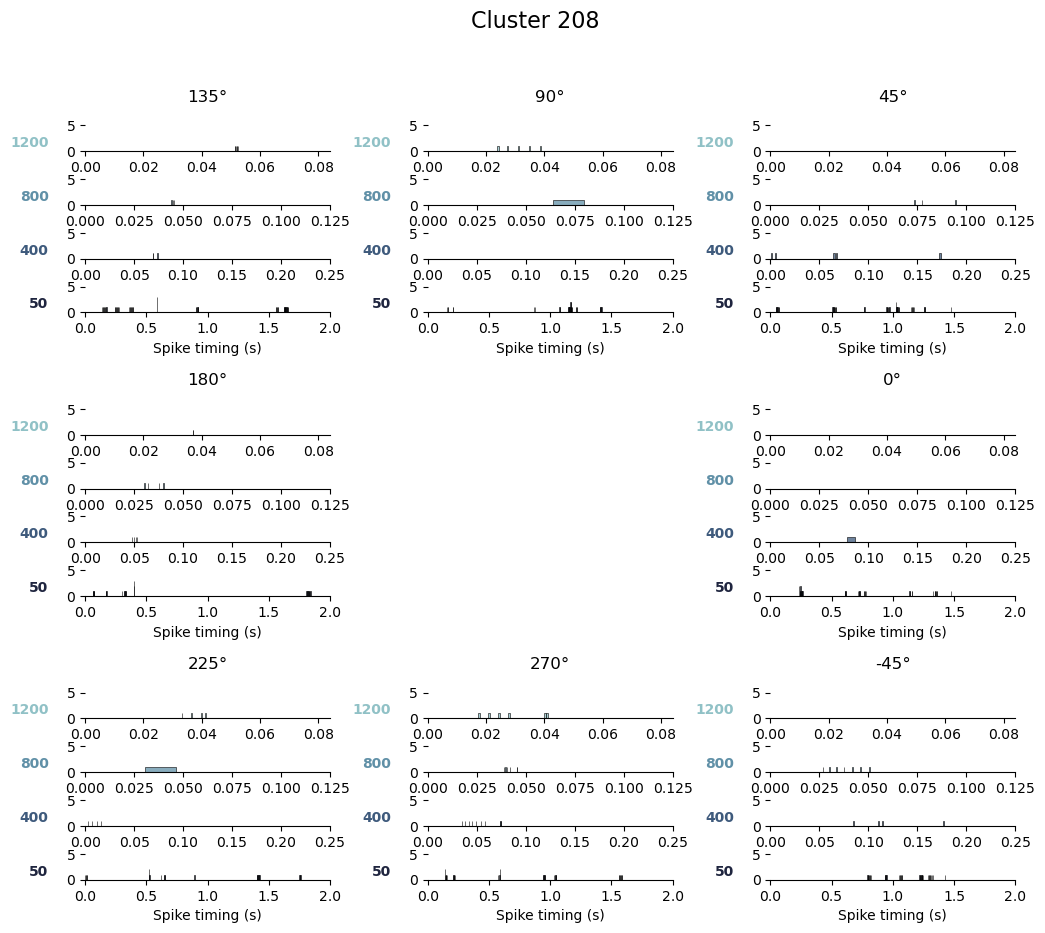

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


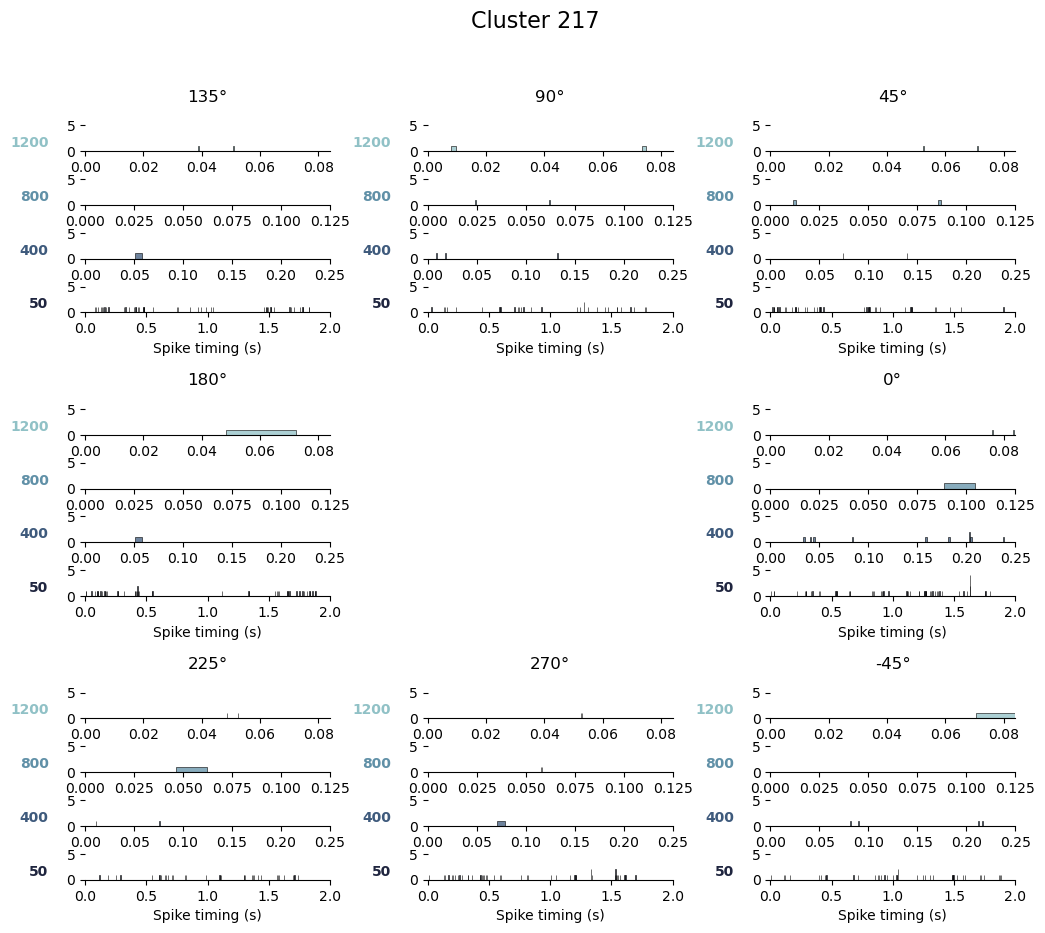

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


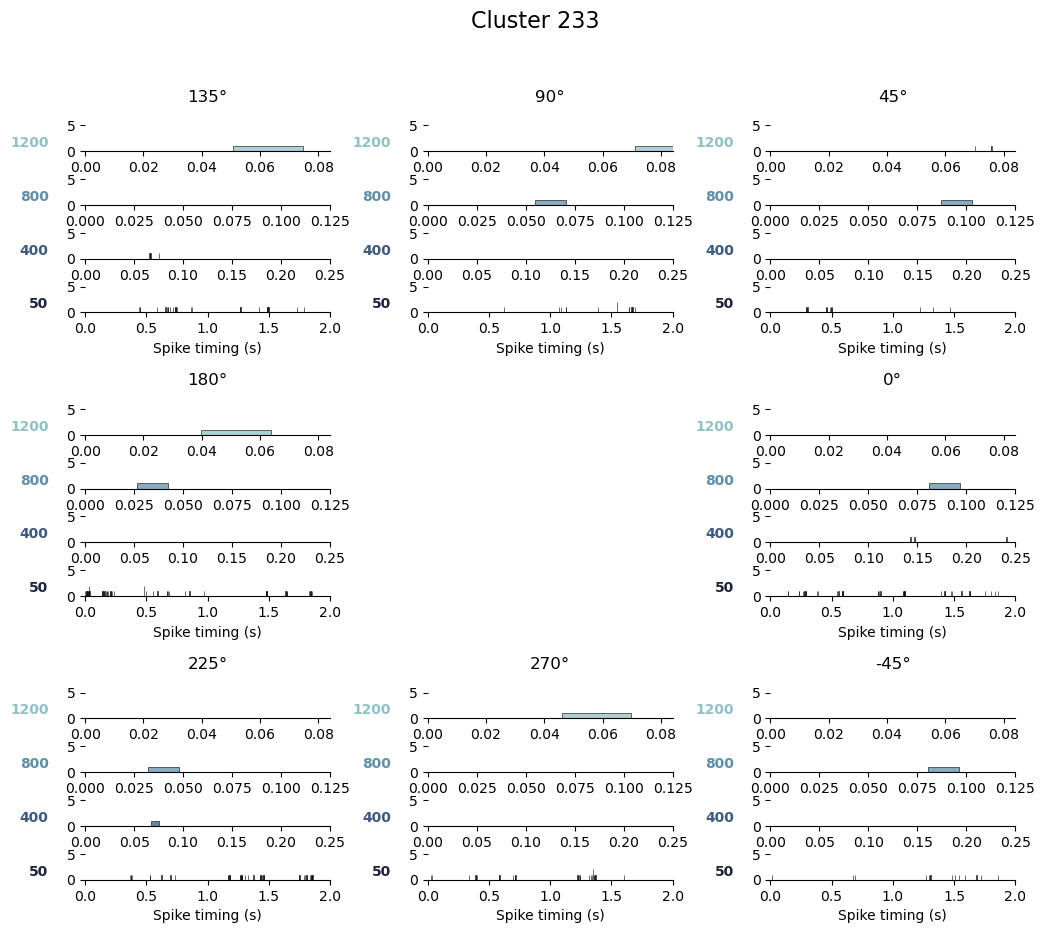

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


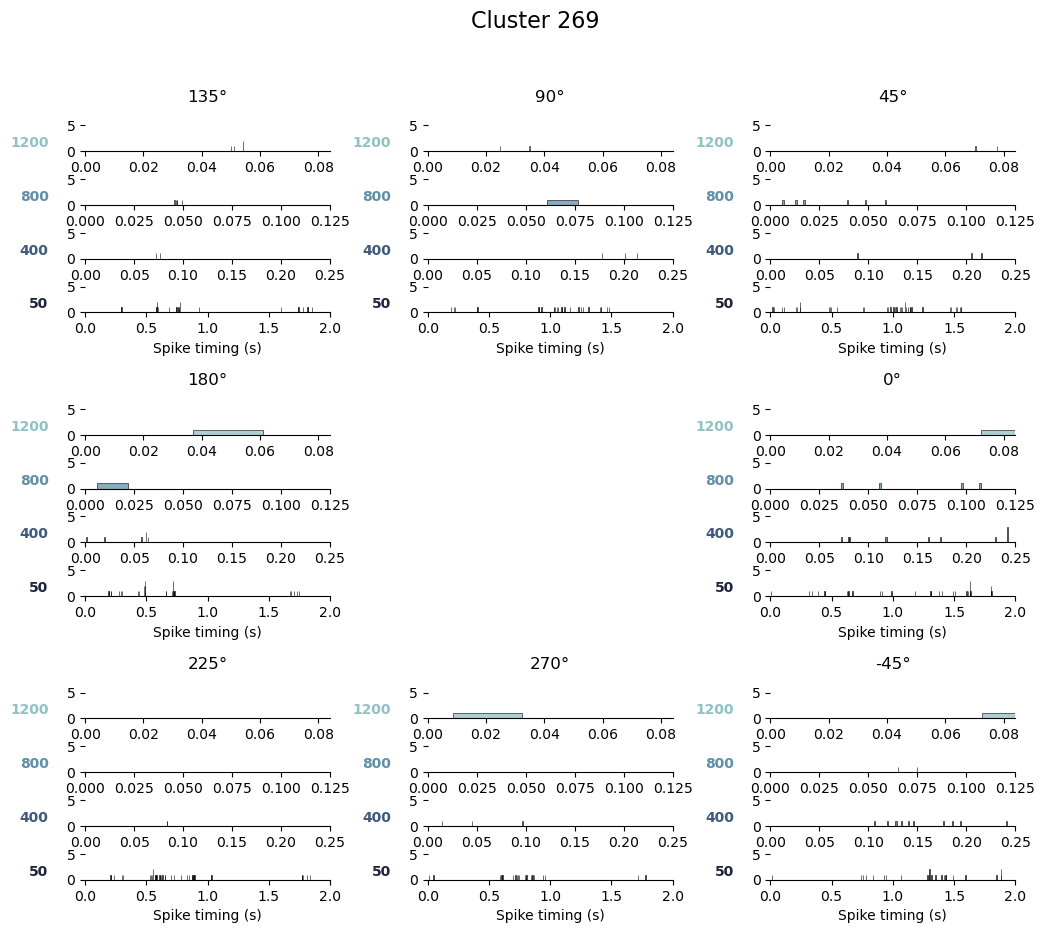

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


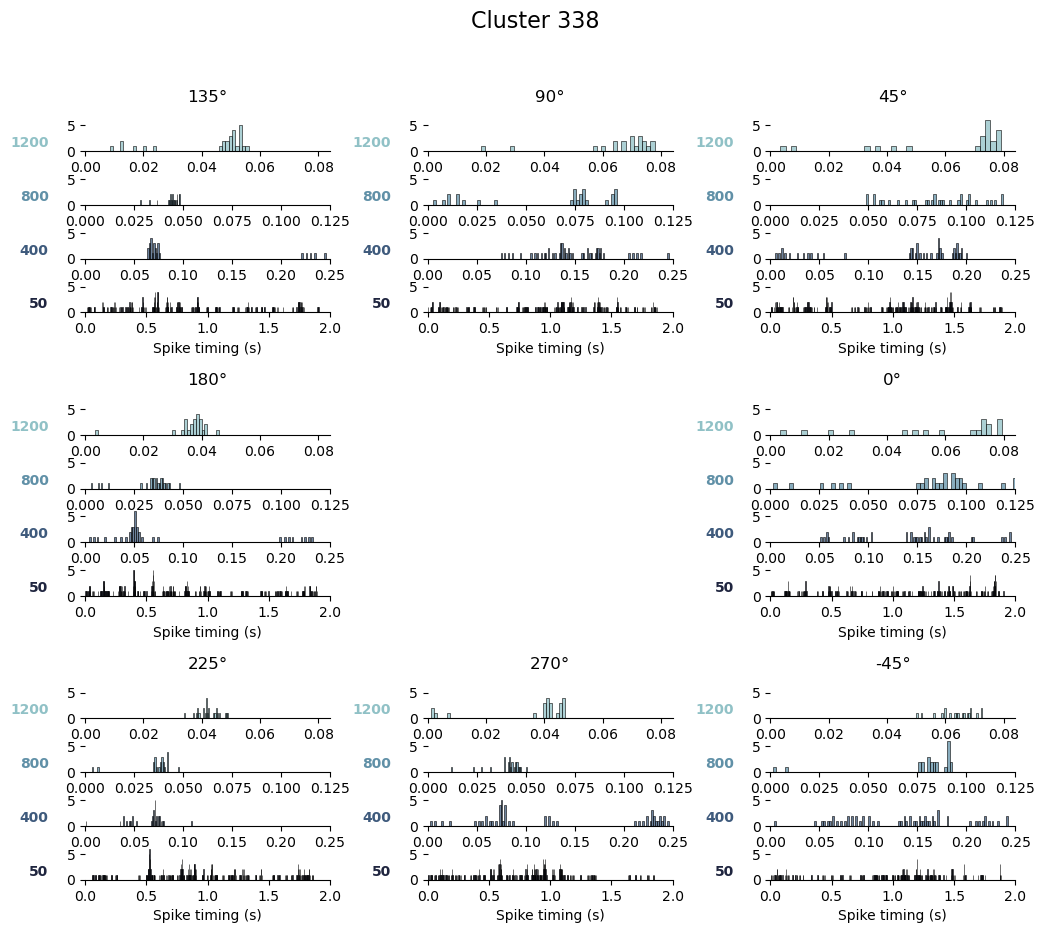

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


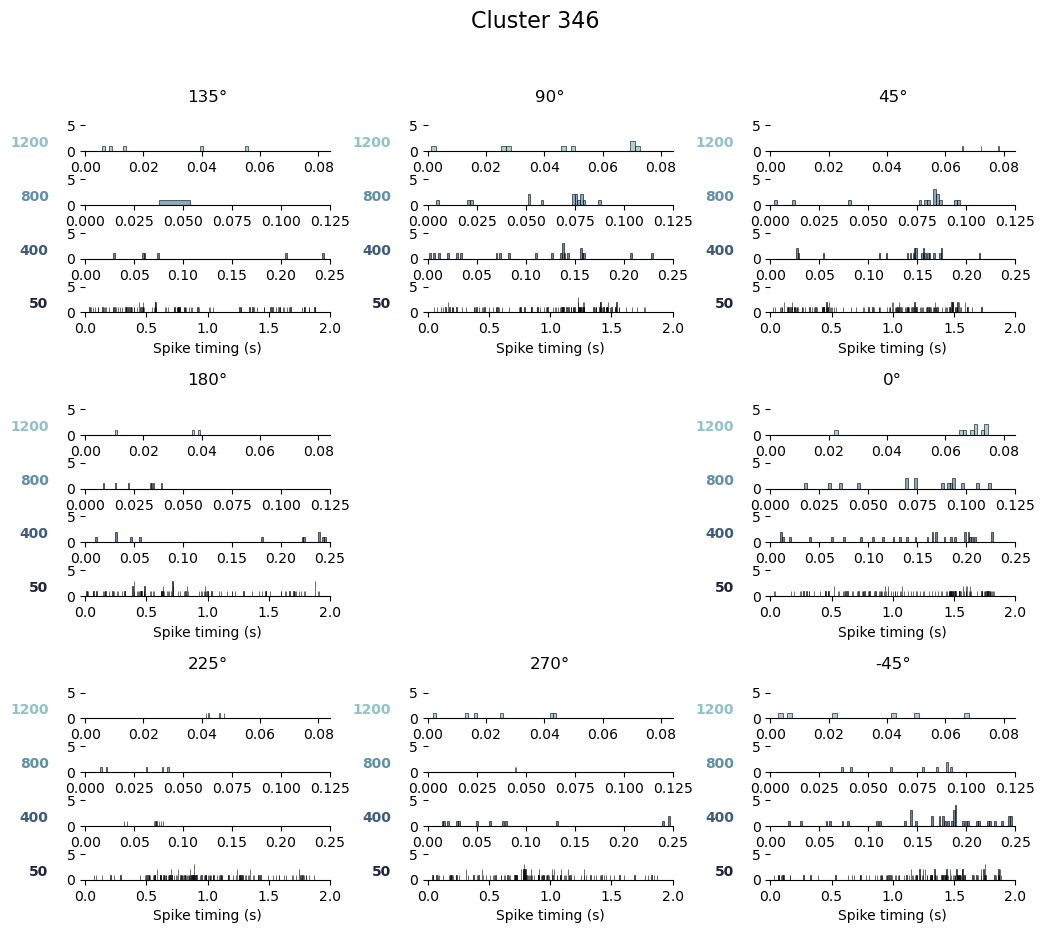

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


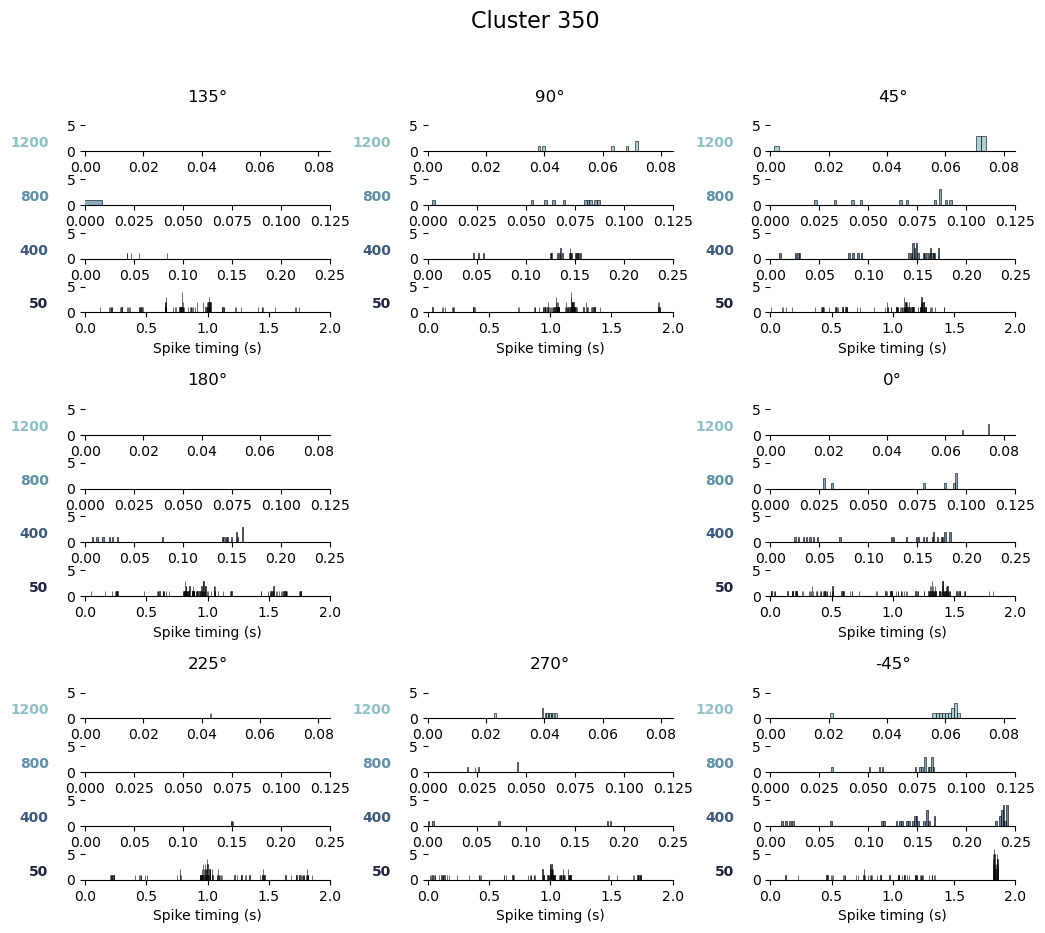

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


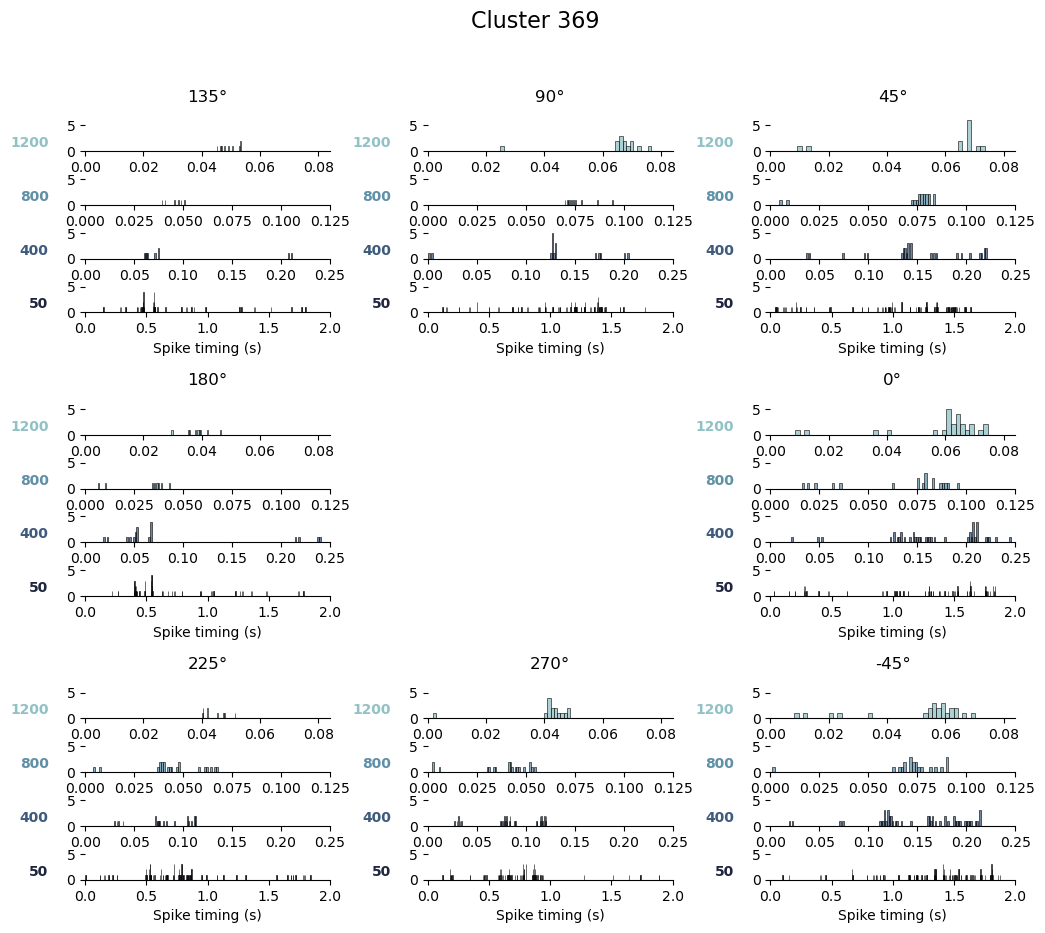

C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  start_time = pd.to_datetime(data["start_time"])
C:\Users\mymcm\AppData\Local\Temp\ipykernel_7228\643643587.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(data["end_time"])


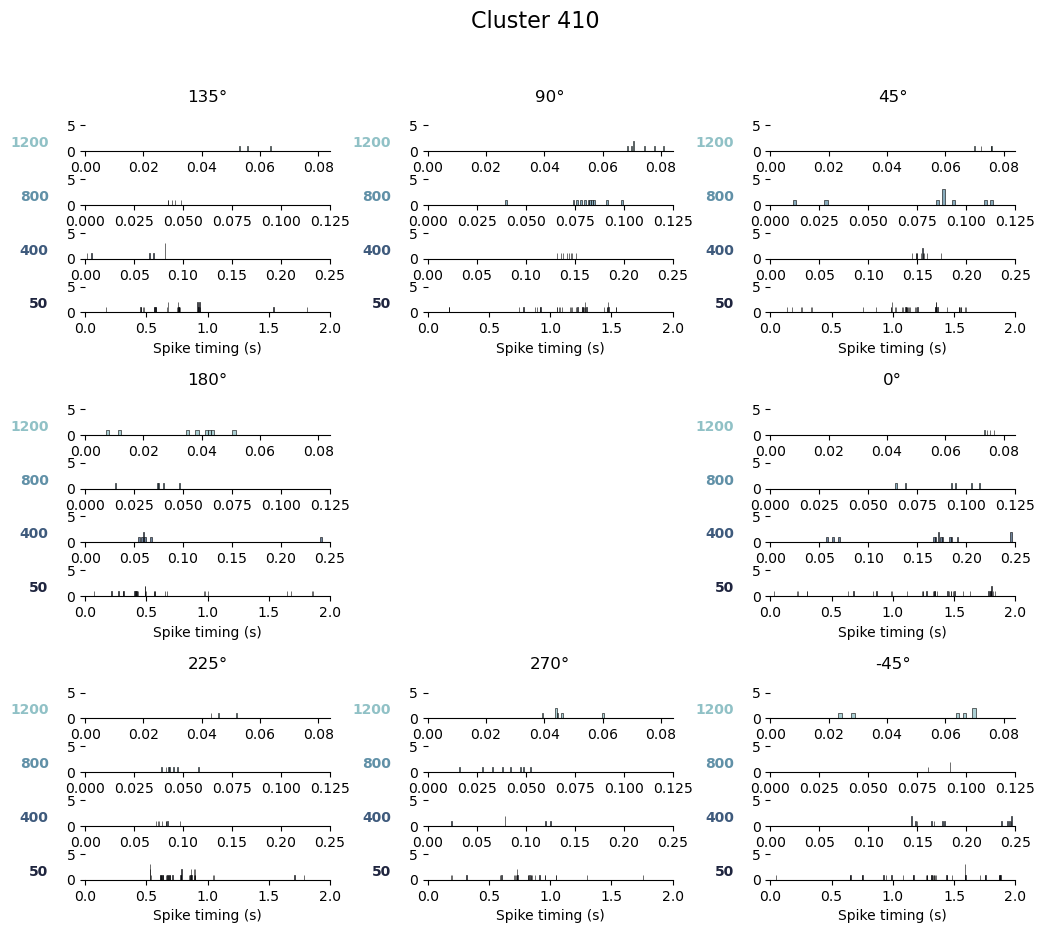

In [76]:
for cluster in bigGoodClusterIDs:
    csvGroup, spList, angList = one_cluster_data(cluster,spike_sec_all,spike_clusters_all)

    ridge_datasets = build_ridge_datasets(cluster, csvGroup, angList, spList)

    plot_cluster(cluster, ridge_datasets, outDir = outDir)